

    Download (or reuse) FITS image m101.fits, which you have used in previous exercise.

    With astropy.io.fits, open the FITS file and use function info() to answer the following questions:

            How many HDU’s are in this FITS file?

            Which HDU contains the image data? What is the index of that HDU in the list?

            What is the number type of the data?

    Read the header keywords and list the first 5 of them. What is the value of BITPIX=? Does it correspond with the data type found in the previous question?

    Read the data in a variable called dat.

            What is the shape of the NumPy array dat.

            Does this correspond to the information returned with info()?

            Does it correspond to the values of the NAXIS keywords in the header?

            What is the contents of the attribute dtype of the array dat

            Check online for the meaning of dtype. Does it correspond to the value in BITPIX=?

    Find and report the following statistical properties of the (flattened, i.e. 1-dim) image data: minimum, maximum, mean, standard deviation, median, mode.

    Make a histogram of the flattened image data and use method matplotlib.axes.Axes.axvline() to draw vertical lines at the positions of the mean, median and mode. Additionally, add labels to each line and show with legend.

    Convert the imaging data into floating point numbers with np.asarray(), and plot the image data.

        Calculate the median of the data and use it as the cutoff in vmin.

        Label the axes with the values in keywords CTYPE1 and CTYPE2.

        Add a locatable colorbar (from week 5 material).

        Add a label to the color bar to show the data units.

    Add a new keyword BUNIT to the header and give it the value “Counts”. Then, write the floating point version of your image data to a new FITS file. Check the FITS Notebook for how to ignore messages about invalid header keywords.



Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

 So 2 HDUs Primary and Bintable Primary
 and its index 2 
 Int16 -> 16 bits per value
['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2']
16
 
 Its 16 which alligns whit what we found in the last question
(530, 530)
 
  530 x 530 picture, which corresponds with the info
530

 Yes so it has 2 dimensions 

>i2

 yes it is right since 2 bytes is 16 bits
BUNIT: 
Counts

 the min = 1507
 the max = 15752
 the mean = 4795.924268422927
 the std = 1848.2526085366376
 the med = 4102.0
 the mode = 3551


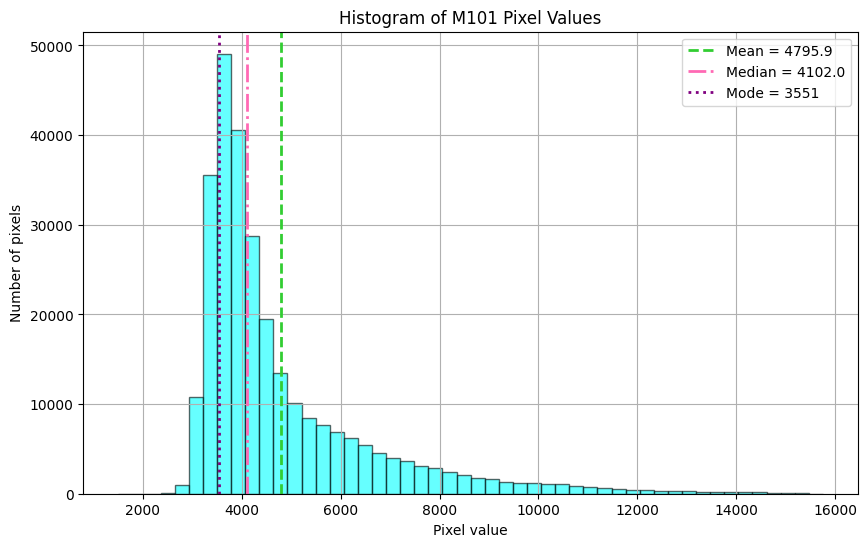

/tmp/ipykernel_2790612/945791245.py:118: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


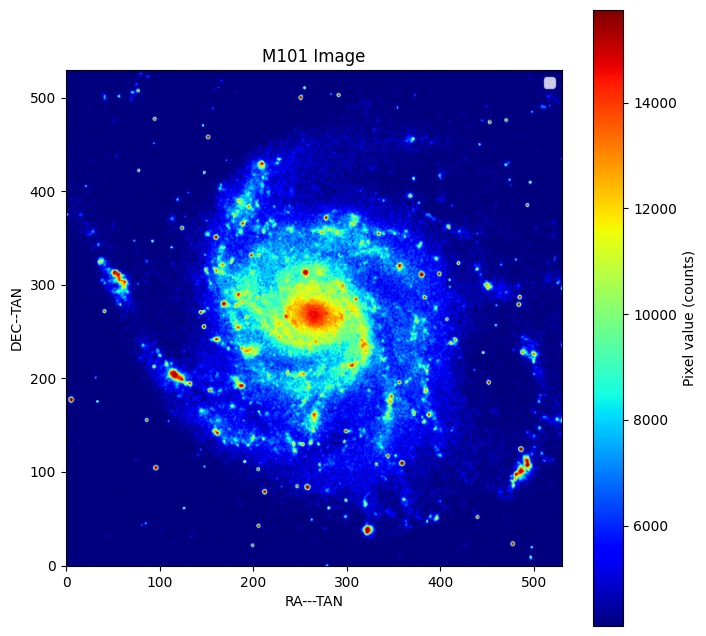

In [47]:
#6.1
from astropy.io import fits
import numpy as np
from scipy import stats
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt


picca = fits.open("m101.fits")
picca.info()

print( f'\n So 2 HDUs Primary and Bintable Primary\n and its index 2 \n Int16 -> 16 bits per value')

pic= picca[0].header
print(list(pic.keys())[:5])   
print(pic["BITPIX"])

print( f' \n Its 16 which alligns whit what we found in the last question' )

dat = picca[0].data
print(dat.shape)

print(f" \n  530 x 530 picture, which corresponds with the info")

print(pic["NAXIS2"])

print(f'\n Yes so it has 2 dimensions \n')

print(dat.dtype)

print(f'\n yes it is right since 2 bytes is 16 bits')



pic["BUNIT"] = "Counts"

print('BUNIT: ')

print(pic["BUNIT"])



# Ignoring messages about invalid headers

hdu = fits.PrimaryHDU(data=dat_float, header=pic)
hdu.writeto("m101_float.fits", overwrite=True, output_verify="silentfix")







# data block
dat_flat = dat.flatten()

minn = np.min(dat_flat)
maxx = np.max(dat_flat)
mean = np.mean(dat_flat)
std = np.std(dat_flat)
med = np.median(dat_flat)

mode_r = stats.mode(dat_flat, keepdims=True)
mode = mode_r.mode[0]


# data block print
print(f'\n the min = {minn}')
print(f' the max = {maxx}')
print(f' the mean = {mean}')
print(f' the std = {std}')
print(f' the med = {med}')
print(f' the mode = {mode}')



# Create figure and axes
fig = plt.figure(figsize=(10,6))
frame = fig.add_subplot(1,1,1)

# Plot histogram
frame.hist(dat_flat, bins=50, color="aqua", edgecolor="black", alpha=0.6)

# Add vertical lines for mean, median, mode
frame.axvline(mean, color='limegreen', linestyle='--', linewidth=2, label=f'Mean = {mean:.1f}')
frame.axvline(med, color='hotpink', linestyle='-.', linewidth=2, label=f'Median = {med:.1f}')
frame.axvline(mode, color='purple', linestyle=':', linewidth=2, label=f'Mode = {mode}')

# Add labels, title, grid, and legend
frame.set_xlabel("Pixel value")
frame.set_ylabel("Number of pixels")
frame.set_title("Histogram of M101 Pixel Values")
frame.grid(True)
frame.legend()

# Show the plot
plt.show()





#plotting floating point number
dat_float = np.asarray(dat, dtype=np.float32)

mean_d_f= np.mean(dat_float)


plt.figure(figsize=(8,8))
plt.imshow(dat_float, cmap='jet', origin='lower', vmin= med)  
plt.title('M101 Image')
plt.xlabel(pic["CTYPE1"])
plt.ylabel(pic['CTYPE2'])
frame.axvline(mean_d_f, color='black', linestyle='--', linewidth=2, label=f'Mean = {mean_d_f:.1f}')
#Colorbar labaling
cbar = plt.colorbar()
cbar.set_label("Pixel value (counts)")
plt.legend()
plt.show()



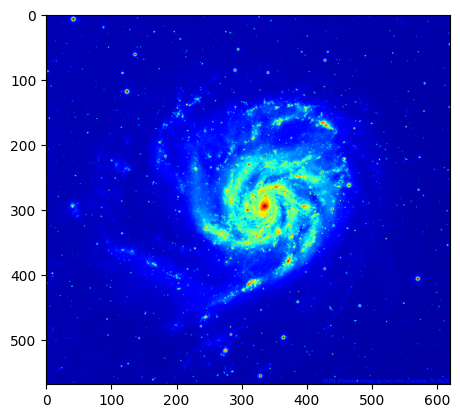

In [7]:
import imageio.v2 as im
import matplotlib.pyplot as plt

x= im.imread("m101BW-Copy1.jpg")

plt.imshow(x, cmap= 'jet')



Find a rectangular area (e.g. 20x20 pixels) in the image of m101.fits where is noise background. Inspect an image with either imshow() or ds9. For your own device, ds9 can be downloaded from saoimageds9.

Define a slice for that area and extract the data.

Analysing an calculating the RMS (Root mean square) of the pixels in the chosen area: 

    What is the RMS in your selected area?

    What is the mean and standard deviation of these pixels? Why does the standard deviation differ from the RMS?

    Which of the two methods (RMS or standard deviation) does quantify noise in your image best? Give explanation and your insight.


 RMS = 58.40963105516076
 mean = 3411.685
 std = 246.07603657203194
 they differ because RMS is overal magnitude while the std is about the varation around the mean
 
 Standard deviation is basically the RMS of 
 the signal after the mean value has been removed. 
 It is excellent for analyzing noise that has a zero-mean


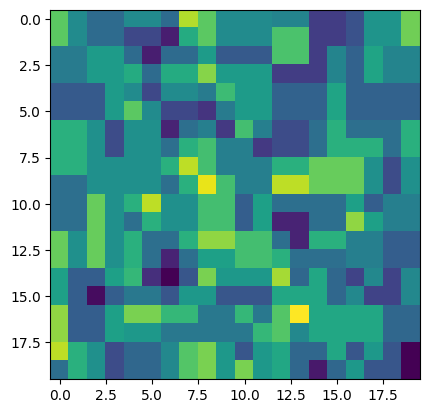

In [32]:
# 6.3

from astropy.io import fits
import numpy as np
from scipy import stats
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import imageio.v2 as im

fliep = fits.open("m101.fits")
floep= fliep[0].data.astype(float)
flabadaba= floep[60:80, 60:80]


mean= np.mean(flabadaba)
std= np.std(flabadaba)


RMS=(mean)**0.5


print(f' RMS = {RMS}')
print(f' mean = {mean}')
print(f' std = {std}')

print(f' they differ because RMS is overal magnitude while the std is about the varation around the mean')
print(f' \n Standard deviation is basically the RMS of \n the signal after the mean value has been removed. \n It is excellent for analyzing noise that has a zero-mean')

plt.imshow(flabadaba)



Download noisemap0.fits, noisemap1.fits and noisemap2.fits. These are all images which only contain noise.


Calculate the standard deviation in each of these images.

Stack the images in a 3D structure with numpy.stack() in the Z direction.

Use np.mean(axis=n) to create an image which is the mean of the three images.  n is the integer that sets the direction in which the mean is calculated.

Calculate the standard deviation for all pixels in this mean image.

Does the standard deviation corresponds to the one we calculate with:
(see section Reducing noise with a stack of images in the notebook about FITS)

In [6]:
#6.5
import math
from astropy.io import fits
import numpy as np

# downloading
a= fits.open('noisemap0.fits')
b= fits.open('noisemap1.fits')
c= fits.open('noisemap2.fits')

#converting
aa= a[0].data.astype(float)
bb= b[0].data.astype(float)
cc= c[0].data.astype(float)

#std's
std_a= np.std(aa)
std_b= np.std(bb)
std_c= np.std(cc)

print(std_a)
print(std_b)
print(std_c)



# Stack along Z-axis (new axis)
stack = np.stack((aa, bb, cc), axis=0)

print(stack.shape)
print(f' ^  since the first is the z value we can see we stacked them in the right way')

de_blok= np.mean(stack, axis=0)
de_b= np.std(de_blok)


print(de_blok.shape)
print(de_b)

# list all the original stds
stds = [std_a, std_b, std_c]

# alternitave calculation
def sigma(sigmas):
    return (1 / len(sigmas)) * math.sqrt(sum(s**2 for s in sigmas))

print(sigma(stds))
print('they are almost the same')

9.98401556679484
10.003955116338458
9.995349488722516
(3, 893, 891)
 ^  since the first is the z value we can see we stacked them in the right way
(893, 891)
5.773191380233297
5.770294583366139
they are almost the same


Each new term in the Fibonacci sequence is generated by adding the previous two terms. Let's start with 0 and 1, the first few terms will be:

0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, ...
Here, create an object called "Fibonacci". 

class Fibonacci:
	"""Class for calculating Fibonacci sequence"""
Create two functions inside this object that returns: 

the N-th term Fibonacci number 
all Fibonacci numbers less than N-th term that can be divided by M. N and M are input parameters of the function.
Include a test in your report for N = 100, M = 7



In [16]:
#6.14
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def nth(self, N):
        a, b = 0, 1

        for _ in range(N - 1):
            a, b = b, a + b

        return a

    def div(self, N, M):
        a, b = 0, 1
        res = []

        for _ in range(N):
            if a % M == 0:
                res.append(a)

            a, b = b, a + b

        return res


fib = Fibonacci()



# test
# print(fib.nth(100))
# print(fib.div(100, 7))

N= int(input('the N-th term of the fibonacci sequence: ...'))
M= int(input('that can be divided by : ...'))

print(f'the N-th term of the fibonacci sequence is : {fib.nth(N)}')
print(f'all Fibonacci numbers less than N-th term that can be divided by M : {fib.div(N, M)}')
         
    

the N-th term of the fibonacci sequence: ... 100
that can be divided by : ... 7


the N-th term of the fibonacci sequence is : 218922995834555169026
all Fibonacci numbers less than N-th term that can be divided by M : [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]


Download (or reuse) the tabular data, APOGEE_stars.fits. 

    Use the following code to read the FITS file. 
        What is the difference between reading an image and reading a table using astropy.io.fits?
        What are the difference in their data structure? 
        
        
        
Recall to your previous exercise, we have listed some criteria for better data quality. Create a new flag called "DATAFLAG" -- if the data satisfy the following criteria, DATAFLAG==1; if not, then 0. 

    STARFLAG == 0
    ASPCAPFLAG == 0
    SNR > 10
    GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

Check astropy.table for instructions on how to modify table data. Add this new flag, DATAFLAG, as a new column into the table. 
Recall to your previous exercise, the table provides apparent magnitude in G-band, "GAIAEDR3_PHOT_G_MEAN_MAG".  Convert the apparent magnitude into absolute magnitude using Distance Modulus: 


Add a new column of the absolute magnitude. If the DATAFLAG==0, then fill the absolute magnitude with a value of -1.0.
Output the updated table as a new file, named "APOGEE_update.fits".
Show your new FITS file, and the newly created columns to TA/lecturer.


In [9]:
#6.6

from astropy.io import fits
import pandas as pd
import numpy as np
from astropy.table import Table


# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names


# print(data)
# print(hdul)


print(f' Image: can be multidimensional and is an np.array ')   
print(' reading: 2 dimensional columns have names' )


# Load the FITS file into a table called df
df = Table.read("APOGEE_stars.fits")


# Create a mask (True/False array) that checks all quality conditions
mask = (
    (df["STARFLAG"] == 0) &
    (df["ASPCAPFLAG"] == 0) &
    (df["SNR"] > 10) &
    (df["GAIAEDR3_PARALLAX"] / df["GAIAEDR3_PARALLAX_ERROR"] > 5) &
    (~np.isnan(df["GAIAEDR3_PHOT_G_MEAN_MAG"])) &
    (~np.isnan(df["GAIAEDR3_PHOT_BP_MEAN_MAG"])) &
    (~np.isnan(df["GAIAEDR3_PHOT_RP_MEAN_MAG"]))
)


# Create a new column DATAFLAG and set all values to 0 
df['DATAFLAG'] = 0

# Set DATAFLAG = 1 only where the mask is True (good data)
df['DATAFLAG'][mask] = 1 


# convinience
m_G = df['GAIAEDR3_PHOT_G_MEAN_MAG']
px = df['GAIAEDR3_PARALLAX']

# validading
valid_px = px > 0
abs_mag = np.full(len(px), -1.0)
abs_mag[valid_px] = m_G[valid_px] - 5 * np.log10(px[valid_px]/1000) + 5



# Create final ABSOLUTE_MAG column:
# if DATAFLAG == 1 → use computed value
# if DATAFLAG == 0 → keep -1.0
df['ABSOLUTE_MAG'] = np.where(df['DATAFLAG'] == 1, abs_mag, -1.0)


# Save the updated table to a new FITS file
df.write('APOGEE_update.fits', format = 'fits', overwrite = True)

print(df['ABSOLUTE_MAG'])
print(df['DATAFLAG'])

 Image: can be multidimensional and is an np.array 
 reading: 2 dimensional columns have names
   ABSOLUTE_MAG   
------------------
              -1.0
              -1.0
              -1.0
              -1.0
31.653636932373047
              -1.0
  31.5665283203125
               ...
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
              -1.0
Length = 733901 rows
DATAFLAG
--------
       0
       0
       0
       0
       1
       0
       1
     ...
       0
       0
       0
       0
       0
       0
       0
Length = 733901 rows


The table shows a selection of measured apparent magnitude and flux in SI units (W m-2 Hz-1) for different color bands measured by GAIA.

    Create a Pandas DataFrame of the CSV data.

    What is the maximum value in column phot_g_mean_flux? Display the entire row of the source that corresponds to this maximum?

    Sort your DataFrame by column phot_g_mean_flux. Now use the values in phot_g_mean_flux and phot_g_mean_mag as X and Y values in a scatter plot (use Object-Oriented Plotting).


42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  
Value for m0: 25.68840037029544


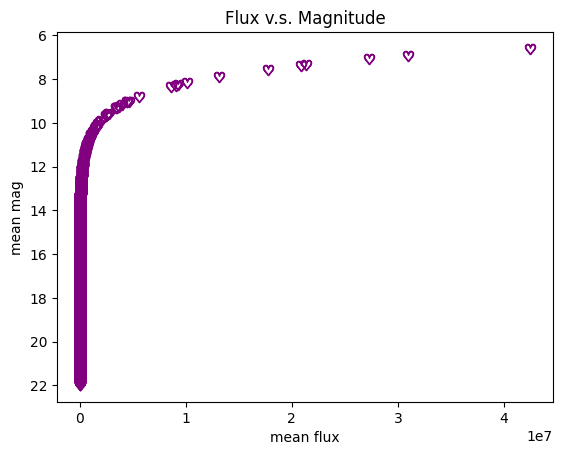

In [37]:
#6.7


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('gaiaTestData.csv')

#print(df)

# Find the maximum value in the column
max_flux = df["phot_g_mean_flux"].max()

# Find the row(s) where the column equals this maximum
max_row = df[df["phot_g_mean_flux"] == max_flux]

print(max_flux)
print(max_row)


# Devining stuff
mg = df["phot_g_mean_mag"]
F_g = df["phot_g_mean_flux"]


#formula
m0 = mg+2.5* np.log10(F_g)
print(f"Value for m0: {m0.mean()}")


# Sorting the DataFrame by phot_g_mean_flux 
df_s = df.sort_values(by="phot_g_mean_flux")

# Creating a figure and axis 
fig, ax = plt.subplots()


ax.scatter(
    df_s["phot_g_mean_flux"],   
    df_s["phot_g_mean_mag"],
    s= 55, color= 'purple', marker= '$\heartsuit$'
)
ax.set_xlabel('mean flux')
ax.set_ylabel('mean mag')
ax.set_title('Flux v.s. Magnitude')
ax.invert_yaxis()
plt.show()


Use astroquery to retrieve GAIA data:

from astroquery.gaia import Gaia


    Query the following columns of random 50 data from GAIA DR3, satisfying the selection criteria:
        Requested columns: source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
        Selection criteria 
            GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
            GAIAEDR3_PHOT_G_MEAN_MAG is not empty
            GAIAEDR3_PHOT_BP_MEAN_MAG is not empty
            GAIAEDR3_PHOT_RP_MEAN_MAG is not empty
    Create Pandas DataFrame of your retrieval. 

In [34]:
#6.10
from astroquery.gaia import Gaia
import pandas as pd

# Telling Gaia what data we want
query = """ 
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5   -- keep only reliable parallaxes
AND phot_g_mean_mag IS NOT NULL       -- require G magnitude
AND phot_bp_mean_mag IS NOT NULL      -- require BP magnitude
AND phot_rp_mean_mag IS NOT NULL      -- require RP magnitude
ORDER BY random_index                 -- randomize selection
"""


# Send to the Gaia database and run it
job = Gaia.launch_job(query)

# results as table
t = job.get_results()

# Convert into a Pandas DataFrame 
tp = t.to_pandas()

print(t)


# Save the table to a FITS file on your computer
t.write("astroquery_gaia.fits", format='fits', overwrite=True)



     SOURCE_ID              ra         ... phot_bp_mean_mag phot_rp_mean_mag
                           deg         ...       mag              mag       
------------------- ------------------ ... ---------------- ----------------
4267180339403392768  286.7169128963743 ...        15.942071        14.419943
6709252873623174016     276.6911939192 ...        16.380306        15.151749
4040949706019490560 265.22936348434496 ...        16.118845        13.680644
4517539583701880064 284.02566215626837 ...        16.652264        15.347014
1823532754729083392 300.80580445460237 ...        14.782262        13.795675
3586362911238437248 171.80987737943448 ...        14.809981        12.990531
                ...                ... ...              ...              ...
5631046688815157632 138.49586968485303 ...        17.159462         16.29502
3041605335480028032 113.79875587415445 ...        18.923515        17.105032
4068119119320653568 266.08808554369216 ...        19.989626        17.876837